# Case 3: Klastering Tingkat Adopsi Digitalisasi

Mengelompokkan UMKM berdasarkan seberapa melek teknologi mereka dalam memanfaatkan sarana media elektronik untuk jualan.

**Fokus Fitur yang Digunakan:**
- Skor Digitalisasi
- Omset Numeric
- Sektor Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [2]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Skor Digitalisasi', 'Omset Numeric', 'Sektor Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Skor Digitalisasi,Omset Numeric,Sektor Numeric
0,NASYWA SNACK,2,5.0,20
1,WARUNG ABINAYA,3,5.0,20
2,TUNGKU MA ENDANG,2,5.0,20
3,WARUNG BU WIWIK,1,5.0,12
4,WARUNG PNUNG,1,5.0,20


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


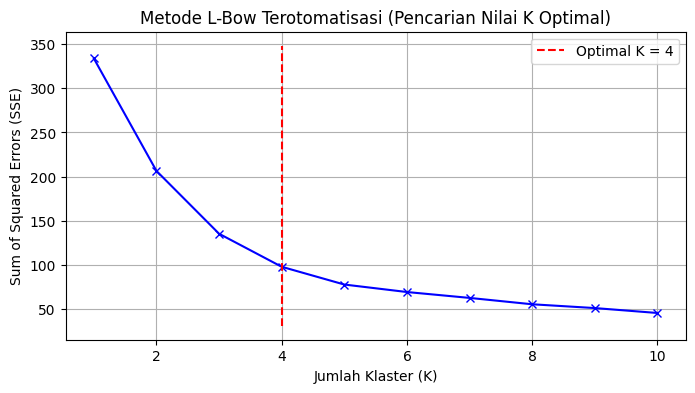

Rekomendasi K-Optimal adalah: 4


In [3]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi Hybrid CSA-KMeans

In [4]:
print(f"Memulai Pencarian Sarang Global (CSA) untuk K={optimal_k}...")
best_cuckoo_centroids_scaled, _ = cuckoo_search_kmeans(X_scaled, k=optimal_k, n_nests=10, max_iter=30, pa=0.25)

print("Mengeksekusi K-Means Final...")
final_labels, final_centroids_scaled = final_kmeans(X_scaled, best_cuckoo_centroids_scaled)

df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Memulai Pencarian Sarang Global (CSA) untuk K=4...
Mengeksekusi K-Means Final...


,Nama Usaha,Skor Digitalisasi,Omset Numeric,Sektor Numeric,Cluster
0,NASYWA SNACK,2,5.0,20,C2
1,WARUNG ABINAYA,3,5.0,20,C2
2,TUNGKU MA ENDANG,2,5.0,20,C2
3,WARUNG BU WIWIK,1,5.0,12,C2
4,WARUNG PNUNG,1,5.0,20,C2
5,KRISNA TRANSPORT,2,5.0,23,C2
6,LAUNDRY WINA,1,5.0,12,C2
7,JP CATERING,1,17.5,16,C2
8,SANDANG TRIAN,1,5.0,20,C2
9,JUALAN ES KELAPA MUDA,1,17.5,20,C2


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


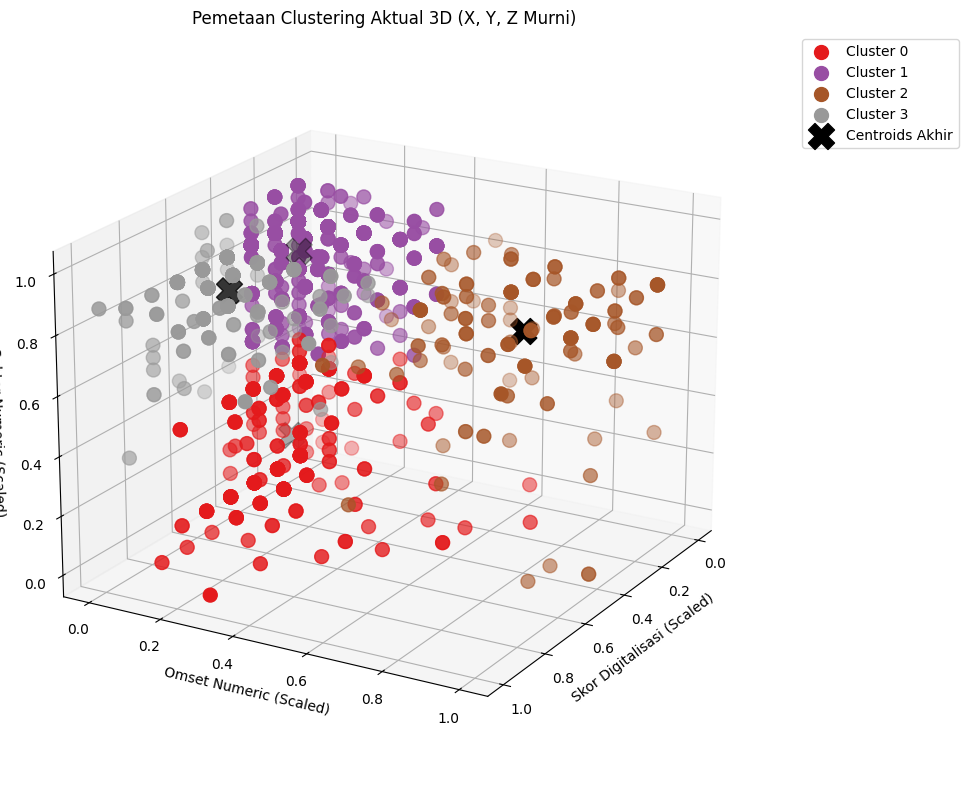


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.4668
   [Interpretasi]: LEMAH. Klaster saling berdekatan / sedikit tumpang tindih.

2. Davies-Bouldin Index (DBI): 0.7540
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 2007.8489
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 101.0335
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.2707
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [5]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [6]:
import plotly.express as px

# =========================================================
# 1. Visualisasi 3D Interaktif (Digitalisasi vs Omset vs Sektor)
# =========================================================
fig_3d_c3 = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Skor Digitalisasi
    y=fitur_yang_dipakai[1], # Omset Numeric
    z=fitur_yang_dipakai[2], # Sektor Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Peta 3D: Hubungan Digitalisasi, Omset, dan Sektor Usaha",
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_3d_c3.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d_c3.show()


# =========================================================
# 2. Bar Chart (Pembandingan Profil Rata-rata)
# =========================================================
# Mengambil rata-rata dari setiap klaster
df_avg_c3 = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Melakukan transformasi data agar pas dengan format Plotly
df_melted_c3 = df_avg_c3.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Metrik', value_name='Nilai Rata-rata')

# Menggambar diagram batang
fig_bar_c3 = px.bar(
    df_melted_c3, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Metrik', 
    barmode='group',
    title="Distribusi Rata-rata Metrik Digitalisasi per Klaster"
)
fig_bar_c3.show()
